# Smartphone Usage & Productivity Analysis

## Objective
Explore how smartphone behavior influences productivity, stress, and sleep patterns.

Key Questions:
- Does heavy phone usage reduce productivity?
- How does social media usage affect stress levels?
- Is sleep related to phone usage behavior?

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv      # or ydata_profiling
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")
%matplotlib inline

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\sweetviz\graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


### Load Engineered Dataset

In [2]:
df = pd.read_parquet("../data/processed/features.parquet")

Dataset Overview

In [3]:
df.head()

,User_ID,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,...,work_life_balance,late_night_user,stress_risk_index,productivity_loss_score,weekend_behavior_shift,distraction_index,stress_sleep_interaction,phone_usage_per_age,productivity_usage_ratio,social_media_addict
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,...,5.076923,0,3.85,1.451667,6.692308,8.71,-3.2,0.022414,4.615385,1
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,...,3.333333,0,3.20,0.360000,4.250000,1.80,1.6,0.048000,4.166667,0
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,...,1.061321,0,5.65,6.042000,1.188679,30.21,-4.0,0.278947,0.943396,1
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,...,0.245690,0,8.20,7.250000,2.206897,14.50,6.9,0.165714,0.344828,0
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,...,0.360759,1,9.25,2.567500,1.253165,10.27,6.9,0.239394,0.506329,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   User_ID                    50000 non-null  string  
 1   Age                        50000 non-null  int8    
 2   Gender                     50000 non-null  category
 3   Occupation                 50000 non-null  category
 4   Device_Type                50000 non-null  category
 5   Daily_Phone_Hours          50000 non-null  float64 
 6   Social_Media_Hours         50000 non-null  float64 
 7   Work_Productivity_Score    50000 non-null  int8    
 8   Sleep_Hours                50000 non-null  float64 
 9   Stress_Level               50000 non-null  int8    
 10  App_Usage_Count            50000 non-null  int16   
 11  Caffeine_Intake_Cups       50000 non-null  int8    
 12  Weekend_Screen_Time_Hours  50000 non-null  float64 
 13  social_media_ratio         5000

In [5]:
df.describe()

,Age,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,social_media_ratio,...,work_life_balance,late_night_user,stress_risk_index,productivity_loss_score,weekend_behavior_shift,distraction_index,stress_sleep_interaction,phone_usage_per_age,productivity_usage_ratio,social_media_addict
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,39.034960,6.509116,4.267250,5.503760,6.497744,5.504500,32.43898,3.004580,8.006844,0.962094,...,1.009448,0.543660,10.261314,8.105638,1.807078,27.780085,8.249644,0.187382,1.241203,0.663560
std,12.414877,3.170903,2.164743,2.874806,1.449551,2.871095,16.12151,1.996657,3.461300,0.991077,...,1.105486,0.498095,3.579054,10.826150,1.752821,20.698121,9.953326,0.118820,1.292995,0.472496
min,18.000000,1.000000,0.500000,1.000000,4.000000,1.000000,5.00000,0.000000,2.000000,0.042017,...,0.041667,0.000000,0.600000,0.050000,0.168067,0.500000,-10.000000,0.016667,0.083333,0.000000
25%,28.000000,3.800000,2.400000,3.000000,5.200000,3.000000,18.00000,1.000000,5.000000,0.366197,...,0.356250,0.000000,7.650000,2.040000,0.754545,10.810000,0.800000,0.096429,0.459770,0.000000
50%,39.000000,6.500000,4.300000,5.500000,6.500000,6.000000,32.00000,3.000000,8.000000,0.653061,...,0.666667,1.000000,10.300000,4.565714,1.223404,22.440000,5.700000,0.166667,0.843373,1.000000
75%,50.000000,9.200000,6.100000,8.000000,7.800000,8.000000,46.00000,5.000000,11.000000,1.142857,...,1.196429,1.000000,12.900000,9.240000,2.135250,40.700000,14.400000,0.248276,1.470588,1.000000
max,60.000000,12.000000,8.000000,10.000000,9.000000,10.000000,60.00000,6.000000,14.000000,8.000000,...,11.250000,1.000000,20.000000,94.010000,13.900000,95.200000,40.000000,0.666667,10.000000,1.000000


In [6]:
df.shape

(50000, 30)

In [7]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type',
       'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score',
       'Sleep_Hours', 'Stress_Level', 'App_Usage_Count',
       'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours',
       'social_media_ratio', 'weekend_usage_increase',
       'productivity_efficiency', 'stress_per_hour', 'sleep_deficit',
       'app_usage_intensity', 'digital_addiction_score', 'work_life_balance',
       'late_night_user', 'stress_risk_index', 'productivity_loss_score',
       'weekend_behavior_shift', 'distraction_index',
       'stress_sleep_interaction', 'phone_usage_per_age',
       'productivity_usage_ratio', 'social_media_addict'],
      dtype='object')

### Missing Values Analysis

In [8]:
df.isnull().sum().sort_values(ascending=False)

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
social_media_ratio           0
weekend_usage_increase       0
productivity_efficiency      0
stress_per_hour              0
sleep_deficit                0
app_usage_intensity          0
digital_addiction_score      0
work_life_balance            0
late_night_user              0
stress_risk_index            0
productivity_loss_score      0
weekend_behavior_shift       0
distraction_index            0
stress_sleep_interaction     0
phone_usage_per_age          0
productivity_usage_ratio     0
social_media_addict          0
dtype: int64

### Visualisation
1. Daily phone Usage

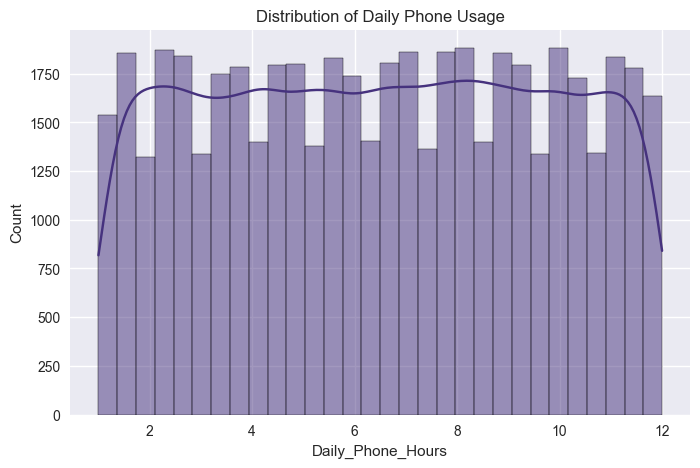

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Daily_Phone_Hours"], bins=30, kde=True)
plt.title("Distribution of Daily Phone Usage")
plt.show()

2. Sleep hours 

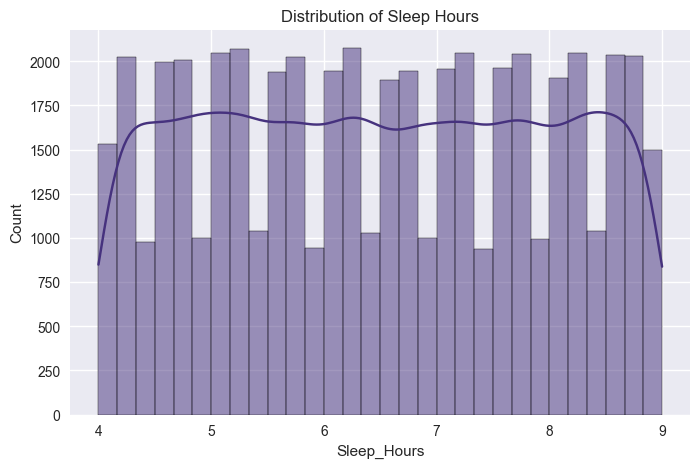

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sleep_Hours"], bins=30, kde=True)
plt.title("Distribution of Sleep Hours")
plt.show()

3. Stress Level

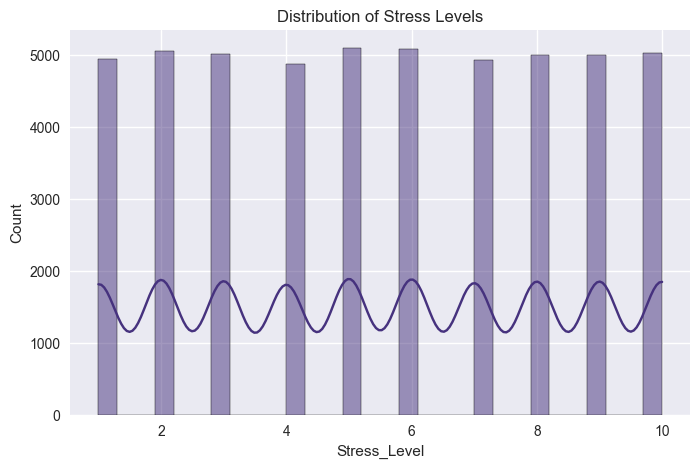

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Stress_Level"], bins=30, kde=True)
plt.title("Distribution of Stress Levels")
plt.show()

### Productivity score

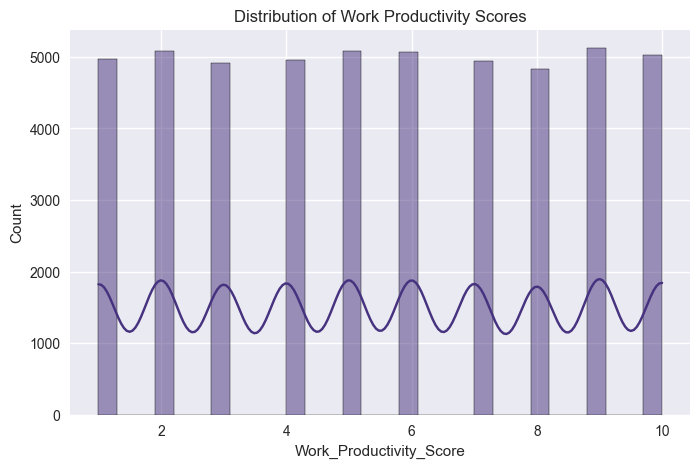

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["Work_Productivity_Score"], bins=30, kde=True)
plt.title("Distribution of Work Productivity Scores")
plt.show()

### Correlation Analysis

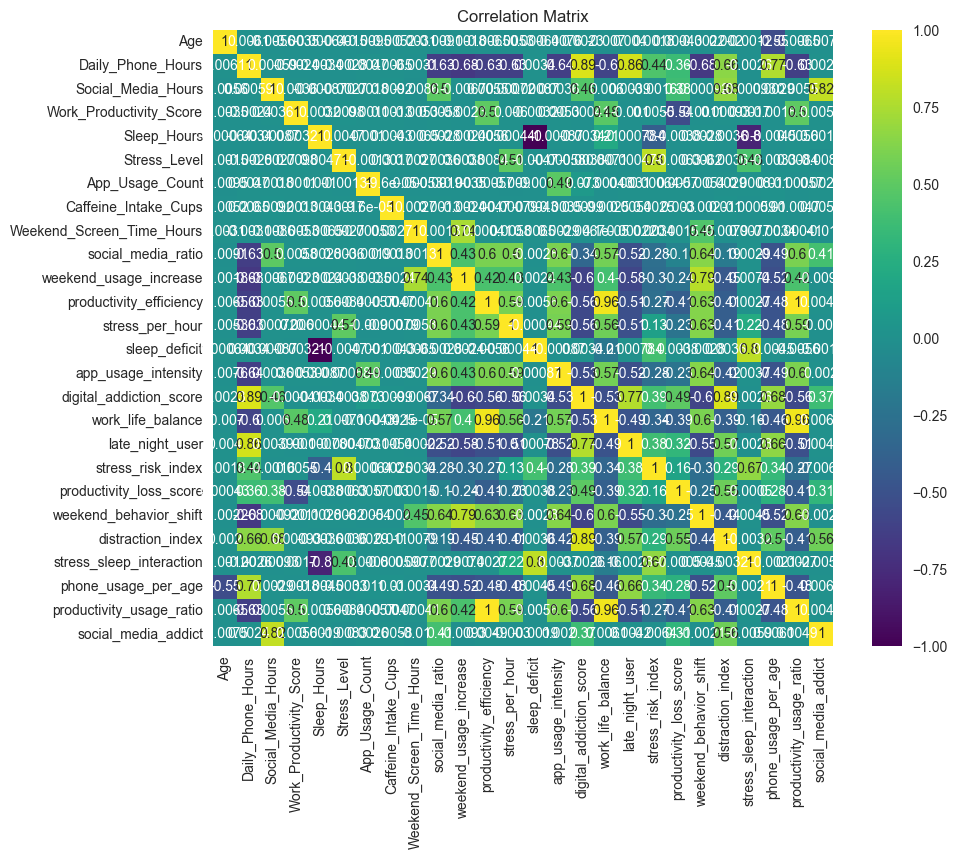

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="viridis"
)

plt.title("Correlation Matrix")
plt.show()

### Behavioral Relationship Analysis

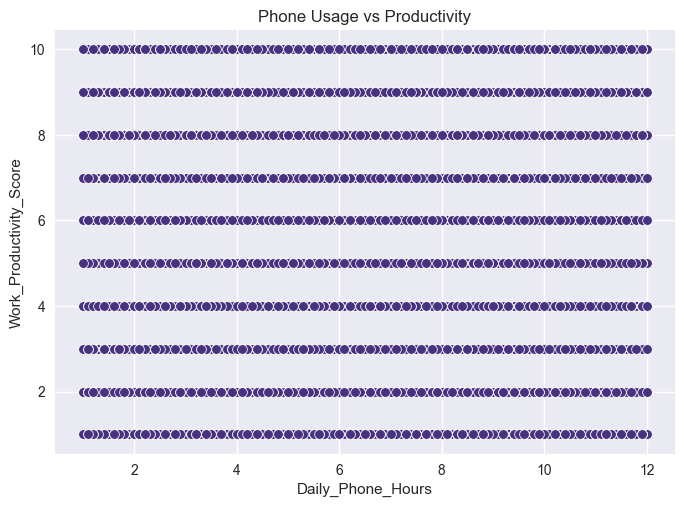

In [14]:
sns.scatterplot(
    x="Daily_Phone_Hours",
    y="Work_Productivity_Score",
    data=df
)

plt.title("Phone Usage vs Productivity")
plt.show()

### Social Media vs Stress

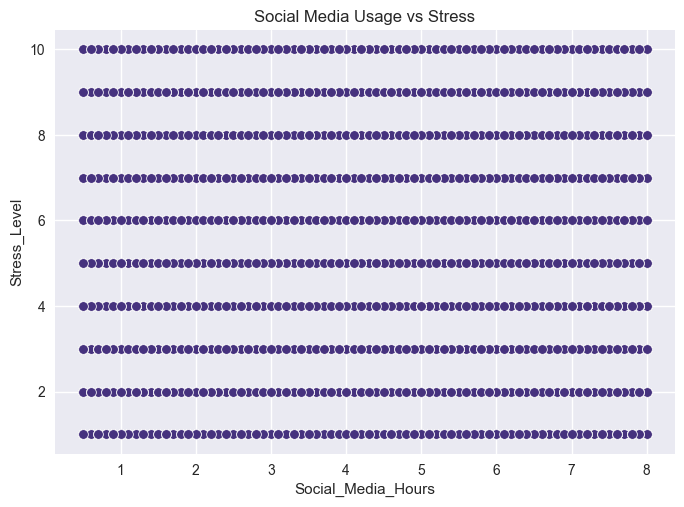

In [15]:
sns.scatterplot(
    x="Social_Media_Hours",
    y="Stress_Level",
    data=df
)

plt.title("Social Media Usage vs Stress")
plt.show()

### Sleep vs Productivity

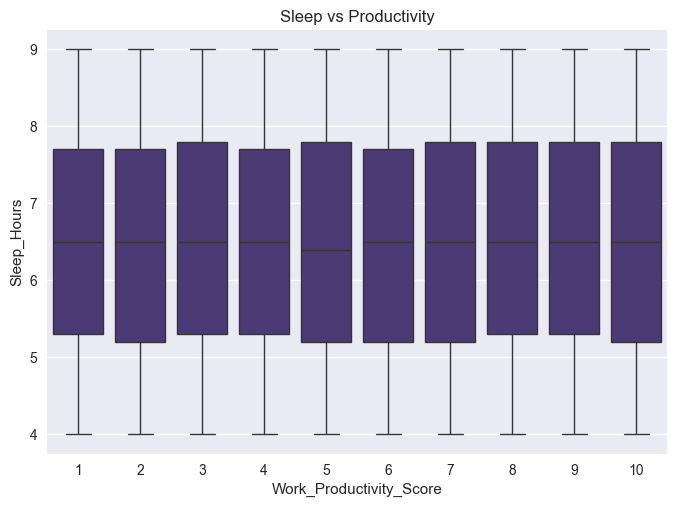

In [16]:
sns.boxplot(
    x="Work_Productivity_Score",
    y="Sleep_Hours",
    data=df
)

plt.title("Sleep vs Productivity")
plt.show()

### Feature Insights

Examine engineered features.

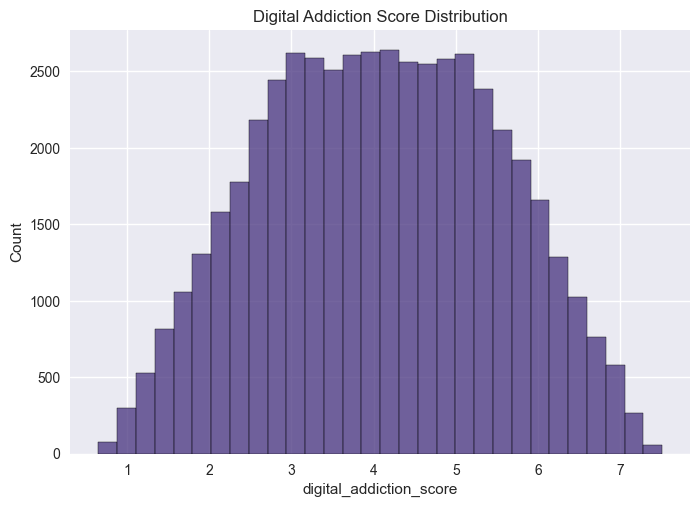

In [17]:
sns.histplot(df["digital_addiction_score"], bins=30)
plt.title("Digital Addiction Score Distribution")
plt.show()

### Categorical Analysis

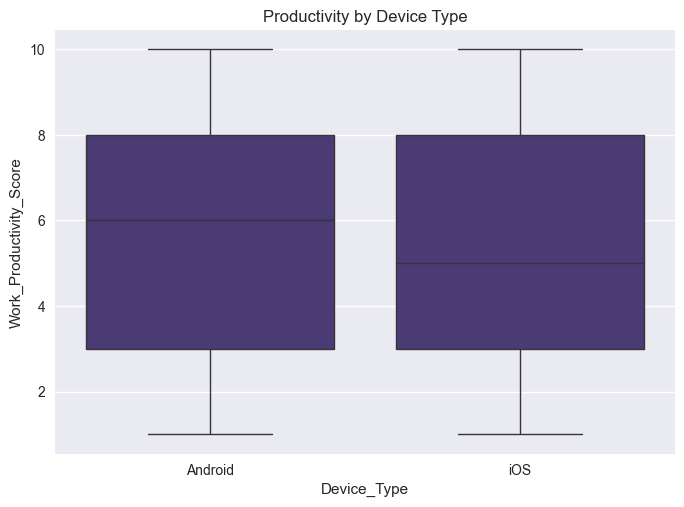

In [18]:
sns.boxplot(
    x="Device_Type",
    y="Work_Productivity_Score",
    data=df
)

plt.title("Productivity by Device Type")
plt.show()

## Insights 


1. Higher daily phone usage appears correlated with lower productivity.
2. Social media usage shows a moderate relationship with stress levels.
3. Users with consistent sleep patterns tend to have higher productivity scores.

## Model Preparation

1. We are predicting the productivity score 

In [19]:
target = df["Work_Productivity_Score"]

#### Select feature ( the input variables)

We then remove the columns we don't need in this model

In [20]:
features = df.drop(columns=["User_ID", "Work_Productivity_Score"])

In [21]:
X = features
y = target

#### Convert Categorical Variables
We convert the dummy variable using one hot encoding

In [22]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,Age,Daily_Phone_Hours,Social_Media_Hours,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours,social_media_ratio,weekend_usage_increase,...,stress_sleep_interaction,phone_usage_per_age,productivity_usage_ratio,social_media_addict,Gender_Male,Gender_Other,Occupation_Freelancer,Occupation_Professional,Occupation_Student,Device_Type_iOS
0,58,1.3,6.7,8.8,4,42,1,8.7,5.153846,7.4,...,-3.2,0.022414,4.615385,1,True,False,False,True,False,False
1,25,1.2,1.5,6.4,1,51,3,5.1,1.250000,3.9,...,1.6,0.048000,4.166667,0,True,False,False,True,False,False
2,19,5.3,5.7,9.0,4,14,5,6.3,1.075472,1.0,...,-4.0,0.278947,0.943396,1,True,False,False,False,True,True
3,35,5.8,2.5,5.7,3,36,6,12.8,0.431034,7.0,...,6.9,0.165714,0.344828,0,False,False,False,False,False,True
4,33,7.9,1.3,5.7,3,37,5,9.9,0.164557,2.0,...,6.9,0.239394,0.506329,0,True,False,True,False,False,False


### Split Data into Training and Testing Sets

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Feature Scaling ( scaling ensures all features are on similar ranges)

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Quick check before modelling 

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)

(40000, 31)
(10000, 31)
(40000,)
